In [4]:
import firedrake
import icepack
print("Ready")

Ready


In [5]:
from __future__ import annotations

import sys

import firedrake
from firedrake import Function, SpatialCoordinate, as_vector, Constant, dx, assemble
import icepack
import icepack.plot
import numpy as np

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?



=== 1. Meshes & plotting ===
  Integrated thickness (m³ per unit width): 416.0
  Boundary segments: [1 2 3 4]


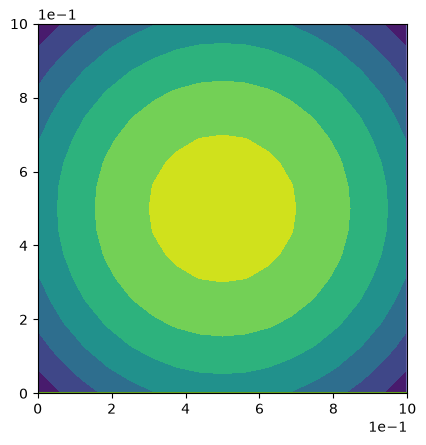

In [6]:
## exercise 1 - meshes and plotting

def exercise1():
    """Firedrake meshes, boundary IDs, symbolic fields, icepack plotting."""
    print("\n=== 1. Meshes & plotting ===")
    mesh = firedrake.UnitSquareMesh(16, 16)
    x, y = SpatialCoordinate(mesh)

    # Symbolic thickness field (parabolic dome)
    Q = firedrake.FunctionSpace(mesh, "CG", 1)
    h = Function(Q).interpolate(500 * (1 - (x - 0.5) ** 2 - (y - 0.5) ** 2))

    volume = assemble(h * dx)
    print(f"  Integrated thickness (m³ per unit width): {float(volume):.1f}")
    print(f"  Boundary segments: {mesh.exterior_facets.unique_markers}")


    fig, axes = icepack.plot.subplots()
    firedrake.triplot(mesh, axes=axes)
    firedrake.tricontourf(h, axes=axes)

exercise1()